<span style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">An Exception was encountered at '<a href="#papermill-error-cell">In [56]</a>'.</span>

In [1]:
import json
import os
from datetime import datetime

RETRAIN_STATUS_FILE = globals().get('status_file_path') or os.path.join(
    'instance',
    'retrain_statuses',
    f"{globals().get('job_id', 'unknown')}.json",
)

RETRAIN_STEP_PLAN = [
    'Load library',
    'Load dataset',
    'Label encoding kolom kategorikal',
    'Visualisasi sederhana EDA',
    'Ambil feature dan label',
    'Split train/test 80/20',
    'SMOTE',
    'Feature scaling',
    'PCA',
    'SVM',
    'HPO SVM',
    'Evaluation',
    'k-NN classifier',
    'HPO dan evaluasi k-NN',
    'Decision Tree',
    'HPO Decision Tree',
    'Neural Network',
    'HPO Neural Network',
    'Tabel perbandingan sebelum HPO',
    'Tabel perbandingan setelah HPO',
    'Confusion matrix Decision Tree',
    'Deploy',
]


def _load_status():
    try:
        with open(RETRAIN_STATUS_FILE, 'r', encoding='utf-8') as handle:
            return json.load(handle)
    except Exception:
        return {
            'job_id': globals().get('job_id'),
            'status': 'running',
            'progress': 0,
            'current_step': None,
            'steps': [{'name': name, 'status': 'pending'} for name in RETRAIN_STEP_PLAN],
            'logs': [],
        }


def _save_status(payload):
    os.makedirs(os.path.dirname(RETRAIN_STATUS_FILE), exist_ok=True)
    with open(RETRAIN_STATUS_FILE, 'w', encoding='utf-8') as handle:
        json.dump(payload, handle, indent=2, ensure_ascii=False)


def checkpoint(step_name, finalize=False, message=None):
    payload = _load_status()
    steps = payload.get('steps') or [{'name': name, 'status': 'pending'} for name in RETRAIN_STEP_PLAN]
    previous = payload.get('current_step')

    for step in steps:
        if previous and step.get('name') == previous and step.get('status') == 'running':
            step['status'] = 'done'
        if step.get('name') == step_name:
            step['status'] = 'done' if finalize else 'running'

    payload['steps'] = steps
    payload['current_step'] = None if finalize else step_name
    payload['status'] = 'success' if finalize else 'running'
    payload['progress'] = round((sum(1 for step in steps if step.get('status') == 'done') / max(len(steps), 1)) * 100, 2)
    payload['finished_at'] = datetime.utcnow().isoformat() + 'Z' if finalize else payload.get('finished_at')
    logs = payload.get('logs', [])
    logs.append({
        'ts': datetime.utcnow().isoformat() + 'Z',
        'level': 'INFO',
        'message': message or (f'RETRAIN SELESAI' if finalize else f'Sedang menjalankan: {step_name}')
    })
    payload['logs'] = logs
    _save_status(payload)


In [2]:
output_model_dir = 'model/model_default'


In [3]:
# Parameters
output_model_dir = "model\\model_20260530_120826"
job_id = "manual_24f608d6751d48fbbeb91a69f9133aea"
status_file_path = "instance\\retrain_statuses\\manual_24f608d6751d48fbbeb91a69f9133aea.json"


#Sistem Deteksi Dini Kecanduan Smartphone Berbasis Web dengan Integrasi Model Machine Learning

##Kelompok 2

# Load library yang dibutuhkan

In [4]:
checkpoint('Load library')

In [5]:
import numpy as np
import pandas as pd
from sklearn import preprocessing
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.feature_selection import SelectKBest, f_regression # Import untuk seleksi fitur
from sklearn.metrics import mean_squared_error, r2_score

# safe drive mounting that works both locally and on Google Colab
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    get_ipython().run_line_magic('cd', '/content/drive/My Drive/dataset_tubes')
    get_ipython().system('ls')
except (ImportError, NameError):
    print("Running locally, skipping drive mount")


Running locally, skipping drive mount


# Load dataset


In [6]:
checkpoint('Load dataset')

In [7]:
# Load data dari file clean_dataset.csv
import os
file_path = 'dataset-notebook/Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv'
if not os.path.exists(file_path):
    file_path = '/content/drive/MyDrive/dataset_tubes/Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv'
df = pd.read_csv(file_path)

# Convert non-numeric columns to object dtype to ensure compatibility with pandas 3.x
for col in df.columns:
    if not pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].astype('object')

print(f"Bentuk dataset: {df.shape}")


Bentuk dataset: (7611, 16)


In [8]:
print(df['addiction_level'].unique())
print(df['addiction_level'].value_counts(dropna=False))

[nan 'Mild' 'Moderate' 'Severe']
addiction_level
Moderate    2927
Severe      2468
Mild        1397
NaN          819
Name: count, dtype: int64


In [9]:
df.head()

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


### Label Encoding untuk Kolom Kategorikal (addiction_level)

In [10]:
checkpoint('Label encoding kolom kategorikal')

In [11]:
from sklearn.preprocessing import LabelEncoder

# Hapus missing value
df = df.dropna()

# Hapus spasi berlebih di semua kolom object/string
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].str.strip()

# Samakan format huruf
# Contoh: severe -> Severe
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].str.title()

# Hapus data duplikat
df = df.drop_duplicates()


# Inisialisasi LabelEncoder
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

print(f"Bentuk dataset setelah label encoding: {df.head}")

Bentuk dataset setelah label encoding: <bound method NDFrame.head of       transaction_id  user_id  age  gender  daily_screen_time_hours  \
2                  0        1   31       2                     6.06   
3                  1        2   32       2                     7.83   
4                  2        3   25       1                     9.96   
5                  3        4   26       1                     9.32   
6                  4        5   25       1                    10.40   
...              ...      ...  ...     ...                      ...   
7606            6787        1   30       0                    11.00   
7607            6788        1    5       0                    17.00   
7608            6789        1   55       1                     8.00   
7609            6790        1   23       0                    20.00   
7610            6791        1   59       0                    22.00   

      social_media_hours  gaming_hours  work_study_hours  sleep_hours  \
2    

In [12]:
df.head()

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
2,0,1,31,2,6.06,1.36,3.83,2.35,4.92,44,106,8.68,0,0,0,0
3,1,2,32,2,7.83,5.85,1.51,3.54,8.23,178,107,9.77,0,1,1,1
4,2,3,25,1,9.96,5.92,3.42,5.27,6.21,136,177,12.55,1,0,2,1
5,3,4,26,1,9.32,4.26,0.29,3.99,6.90,82,56,10.98,2,1,2,1
6,4,5,25,1,10.40,4.93,1.60,0.86,8.61,165,95,11.43,2,0,2,1


### Visualisasi Sederhana (EDA)

In [13]:
checkpoint('Visualisasi sederhana EDA')

addiction_level
1    2927
2    2468
0    1397
Name: count, dtype: int64


C:\Users\hi\AppData\Local\Temp\ipykernel_5320\1695413281.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=addiction_counts.index, y=addiction_counts.values, palette='viridis')


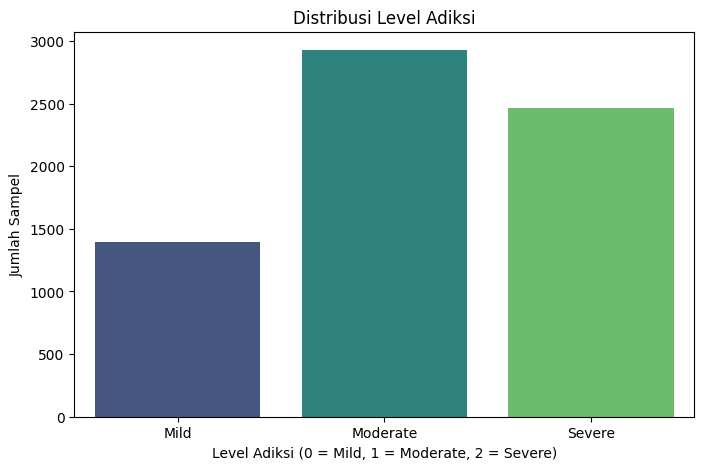

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns # Make sure seaborn is imported

# Mempersiapkan data untuk visualisasi addiction_level
# Karena addiction_level sudah di-encode menjadi 0, 1, 2,
# dan berdasarkan df.head() sebelumnya, urutannya adalah Mild, Moderate, Severe.
labels = ['Mild', 'Moderate', 'Severe']
ticks = range(len(labels))

print(df['addiction_level'].value_counts())

# Membuat barchart dari value_counts() kolom 'addiction_level'
plt.figure(figsize=(8, 5))
addiction_counts = df['addiction_level'].value_counts()
sns.barplot(x=addiction_counts.index, y=addiction_counts.values, palette='viridis')

plt.title('Distribusi Level Adiksi') # Corrected title
plt.xlabel('Level Adiksi (0 = Mild, 1 = Moderate, 2 = Severe)')
plt.ylabel('Jumlah Sampel')
plt.xticks(ticks=ticks, labels=labels)
plt.show()

# Ambil feature dan label yang digunakan dari dataset

In [15]:
checkpoint('Ambil feature dan label')

In [16]:
# Ambil semua kolom
X = df.loc[:,'age':'weekend_screen_time']

# Ambil kolom 'addiction_level' sebagai target (label)
y = df['addiction_level']


print("Fitur (X) head:")
display(X.head())
print("Label (y) head:")
display(y.head())

Fitur (X) head:


,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time
2,31,2,6.06,1.36,3.83,2.35,4.92,44,106,8.68
3,32,2,7.83,5.85,1.51,3.54,8.23,178,107,9.77
4,25,1,9.96,5.92,3.42,5.27,6.21,136,177,12.55
5,26,1,9.32,4.26,0.29,3.99,6.90,82,56,10.98
6,25,1,10.40,4.93,1.60,0.86,8.61,165,95,11.43


Label (y) head:


2    0
3    1
4    2
5    2
6    2
Name: addiction_level, dtype: int64

# Membagi dataset untuk data training (80%) dan data testing (20%)

In [17]:
checkpoint('Split train/test 80/20')

In [18]:
# Membagi data jadi data training dan data testing
# X = fitur (input), y = label (output)
# 20% data jadi data testing, 80% jadi training

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(5433, 10)
(1359, 10)


#SMOTE

In [19]:
checkpoint('SMOTE')

In [20]:
import warnings
warnings.filterwarnings('ignore')

from imblearn.over_sampling import SMOTE

# Inisialisasi SMOTE
smote = SMOTE(random_state=42)

# Terapkan SMOTE pada data training
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Bentuk X_train sebelum SMOTE: {X_train.shape}")
print(f"Bentuk y_train sebelum SMOTE: {y_train.shape}")
print(f"Jumlah kelas di y_train sebelum SMOTE:\n{y_train.value_counts()}")

print(f"\nBentuk X_train setelah SMOTE: {X_train_smote.shape}")
print(f"Bentuk y_train setelah SMOTE: {y_train_smote.shape}")
print(f"Jumlah kelas di y_train setelah SMOTE:\n{y_train_smote.value_counts()}")

# Perbarui X_train dan y_train dengan hasil SMOTE
X_train = X_train_smote
y_train = y_train_smote

Bentuk X_train sebelum SMOTE: (5433, 10)
Bentuk y_train sebelum SMOTE: (5433,)
Jumlah kelas di y_train sebelum SMOTE:
addiction_level
1    2327
2    1977
0    1129
Name: count, dtype: int64

Bentuk X_train setelah SMOTE: (6981, 10)
Bentuk y_train setelah SMOTE: (6981,)
Jumlah kelas di y_train setelah SMOTE:
addiction_level
2    2327
1    2327
0    2327
Name: count, dtype: int64


addiction_level
2    2327
1    2327
0    2327
Name: count, dtype: int64


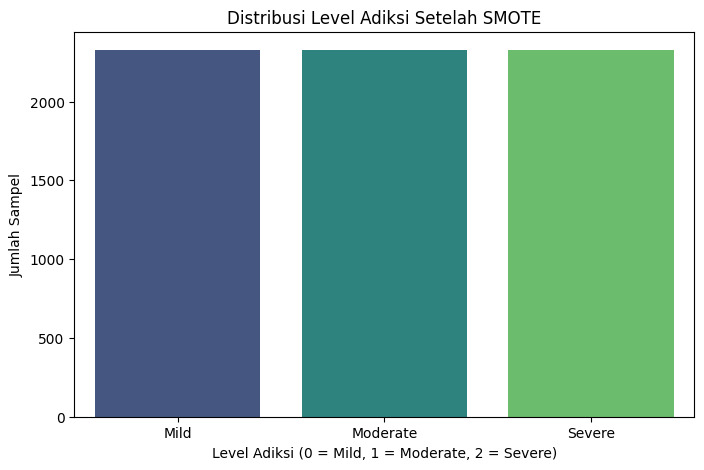

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mempersiapkan data untuk visualisasi y_train_smote
# Karena addiction_level sudah di-encode menjadi 0, 1, 2,
# dan berdasarkan df.head() sebelumnya, urutannya adalah Mild, Moderate, Severe.
labels = ['Mild', 'Moderate', 'Severe']
ticks = range(len(labels))

print(y_train_smote.value_counts())

# Membuat barchart dari value_counts() kolom y_train_smote
plt.figure(figsize=(8, 5))
smote_counts = y_train_smote.value_counts().sort_index()
sns.barplot(x=smote_counts.index, y=smote_counts.values, palette='viridis')

plt.title('Distribusi Level Adiksi Setelah SMOTE')
plt.xlabel('Level Adiksi (0 = Mild, 1 = Moderate, 2 = Severe)')
plt.ylabel('Jumlah Sampel')
plt.xticks(ticks=ticks, labels=labels)
plt.show()

#Feature scaling

In [22]:
checkpoint('Feature scaling')

In [23]:
scaler = StandardScaler()
# Fit scaler pada X_train dan transform X_train
X_train = scaler.fit_transform(X_train);
# Transform X_test dengan scaler yang sama
X_test = scaler.transform(X_test)
print(f"Bentuk X_train setelah Standard Scaling: {X_train.shape}")
print(f"Bentuk X_test setelah Standard Scaling: {X_test.shape}")

Bentuk X_train setelah Standard Scaling: (6981, 10)
Bentuk X_test setelah Standard Scaling: (1359, 10)


#Principal Component Analysis (PCA)

In [24]:
checkpoint('PCA')

In [25]:
# from sklearn.decomposition import PCA

# # Inisialisasi PCA. Kita bisa memilih jumlah komponen atau membiarkan PCA menentukannya
# # Misalnya, kita bisa mencoba 2 komponen utama untuk visualisasi, atau 'None' untuk melihat varians
# # Di sini, kita akan mencoba mengurangi menjadi 2 komponen untuk demonstrasi.
# pca = PCA(n_components=2)

# # Terapkan PCA pada data training dan testing
# X_train_pca = pca.fit_transform(X_train)
# X_test_pca = pca.transform(X_test)

# print(f"Bentuk X_train setelah PCA: {X_train_pca.shape}")
# print(f"Bentuk X_test setelah PCA: {X_test_pca.shape}")

# # Jelaskan variansi yang dijelaskan oleh komponen utama
# print(f"Variansi yang dijelaskan oleh masing-masing komponen utama: {pca.explained_variance_ratio_}")
# print(f"Total variansi yang dijelaskan oleh {pca.n_components_} komponen utama: {sum(pca.explained_variance_ratio_):.2f}")

# # Tampilkan data setelah PCA (beberapa baris pertama)
# print("\nX_train_pca head:")
# # display(pd.DataFrame(X_train_pca, columns=[f'PC{i+1}' for i in range(pca.n_components_)]).head())


#SVM

In [26]:
checkpoint('SVM')

In [27]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report
model_default = SVC(kernel='rbf', C=1000, gamma=0.01, random_state=0)
model_default.fit(X_train, y_train)
pred_default_svm = model_default.predict(X_test)
print(classification_report(y_test, pred_default_svm))

              precision    recall  f1-score   support

           0       0.71      0.90      0.79       268
           1       0.49      0.34      0.40       600
           2       0.48      0.58      0.52       491

    accuracy                           0.54      1359
   macro avg       0.56      0.61      0.57      1359
weighted avg       0.53      0.54      0.52      1359



# HPO untuk SVM

In [28]:
checkpoint('HPO SVM')

In [29]:
from sklearn.svm import SVC

# isi jawaban parameter
param_grid = [
    {'C': [0.1, 1, 10], 'kernel': ['rbf', 'linear'], 'gamma': [0.01, 0.001, 0.0001]}
]

# Inisialisasi SVC dengan probability=True dan random_state=42 seperti yang Anda sebutkan
svc_estimator = SVC(probability=True, random_state=42)

#tolong perhatikan parameter scoring dan cv
classifier = GridSearchCV(SVC(), param_grid, scoring='recall_macro', cv=5, refit = True, verbose = 3)


classifier.fit(X_train, y_train)


print('Parameter terbaik:',classifier.best_params_)

# print how our model looks after hyper-parameter tuning
print(classifier.best_estimator_)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.564 total time=   2.6s


[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.554 total time=   2.6s


[CV 3/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.580 total time=   2.6s


[CV 4/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.604 total time=   2.6s


...

[CV 2/5] END .C=10, gamma=0.0001, kernel=linear;, score=0.572 total time=   6.1s


[CV 3/5] END .C=10, gamma=0.0001, kernel=linear;, score=0.589 total time=   6.1s


[CV 4/5] END .C=10, gamma=0.0001, kernel=linear;, score=0.599 total time=   6.2s


[CV 5/5] END .C=10, gamma=0.0001, kernel=linear;, score=0.583 total time=   6.3s


Parameter terbaik: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
SVC(C=10, gamma=0.01)


#Evaluation (R-squared, MSE, dan Regression Plot)

In [30]:
checkpoint('Evaluation')

In [31]:
from sklearn.metrics import accuracy_score, classification_report

predictions = classifier.predict(X_test)
print('Accuracy:', accuracy_score(y_test, predictions))
print('\nClassification Report:\n', classification_report(y_test, predictions))

Accuracy: 0.5614422369389257

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.93      0.79       268
           1       0.53      0.26      0.35       600
           2       0.51      0.73      0.60       491

    accuracy                           0.56      1359
   macro avg       0.58      0.64      0.58      1359
weighted avg       0.55      0.56      0.53      1359



In [32]:
# # Regression plot (commented out as it's not suitable for classification)
# import matplotlib.pyplot as plt
# fig, ax = plt.subplots()

# ax.text(1, 9.5,'$R^2=$'+str(round(r2_score(y_test, predictions),4)), fontsize=12, verticalalignment='top', multialignment='center')
# ax.text(1, 9,'$MSE=$'+str(round(mean_squared_error(y_test, predictions),4)), fontsize=12, verticalalignment='top', multialignment='center')

# ax.set_xlim(xmin=1)
# ax.set_ylim(ymin=1)
# ax.set_xlim(xmax=10)
# ax.set_ylim(ymax=10)

# ax.set_xlabel('Actual Value', fontsize=14)
# ax.set_ylabel('Predicted Value', fontsize=14)
# ax.scatter(y_test, predictions, s=100, c=y_test, cmap='viridis')

# lims = [
#     np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
#     np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
# ]

# ax.plot(lims, lims, 'r--', alpha=0.75, zorder=0)
# ax.set_aspect('equal')
# ax.set_xlim(lims)
# ax.set_ylim(lims)
# ax.grid(True, which='both')

# xvalue = np.linspace(1,10,10)
# print(xvalue)
# lsigma = ax.fill_between(xvalue, xvalue+1, xvalue-1, color='blue', alpha=0.3)

# plt.show()

#k-NN (KNeighborsClassifier)

In [33]:
checkpoint('k-NN classifier')

In [34]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

knn_before =  KNeighborsClassifier(n_neighbors=5)
knn_before.fit(X_train, y_train)
y_pred = knn_before.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.55      0.84      0.67       268
           1       0.50      0.40      0.45       600
           2       0.50      0.48      0.49       491

    accuracy                           0.52      1359
   macro avg       0.52      0.57      0.53      1359
weighted avg       0.51      0.52      0.50      1359



## HPO dan Evaluasi Model k-NN (KNeighborsClassifier)

In [35]:
checkpoint('HPO dan evaluasi k-NN')

In [36]:
from sklearn.neighbors import KNeighborsClassifier

# Definisikan parameter grid untuk k-NN
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'metric': ['euclidean', 'manhattan', 'minkowski'] # 'chebyshev', 'wminkowski', 'seuclidean', 'mahalanobis' could be problematic with some data/versions
}

# Inisialisasi GridSearchCV untuk k-NN
knn_classifier = GridSearchCV(KNeighborsClassifier(), param_grid_knn, scoring='recall_macro', cv=5, refit=True, verbose=3)

# Latih model
knn_classifier.fit(X_train, y_train)

print('Parameter terbaik k-NN:', knn_classifier.best_params_)
print('Estimator terbaik k-NN:', knn_classifier.best_estimator_)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
[CV 1/5] END ...metric=euclidean, n_neighbors=3;, score=0.593 total time=   0.0s


[CV 2/5] END ...metric=euclidean, n_neighbors=3;, score=0.568 total time=   0.0s
[CV 3/5] END ...metric=euclidean, n_neighbors=3;, score=0.619 total time=   0.0s


[CV 4/5] END ...metric=euclidean, n_neighbors=3;, score=0.613 total time=   0.0s
[CV 5/5] END ...metric=euclidean, n_neighbors=3;, score=0.657 total time=   0.0s


[CV 1/5] END ...metric=euclidean, n_neighbors=5;, score=0.604 total time=   0.0s
[CV 2/5] END ...metric=euclidean, n_neighbors=5;, score=0.591 total time=   0.1s


[CV 3/5] END ...metric=euclidean, n_neighbors=5;, score=0.638 total time=   0.3s


...

[CV 1/5] END ...metric=minkowski, n_neighbors=9;, score=0.608 total time=   0.1s
[CV 2/5] END ...metric=minkowski, n_neighbors=9;, score=0.588 total time=   0.0s


[CV 3/5] END ...metric=minkowski, n_neighbors=9;, score=0.626 total time=   0.1s
[CV 4/5] END ...metric=minkowski, n_neighbors=9;, score=0.629 total time=   0.1s


[CV 5/5] END ...metric=minkowski, n_neighbors=9;, score=0.638 total time=   0.0s
[CV 1/5] END ..metric=minkowski, n_neighbors=11;, score=0.608 total time=   0.1s


[CV 2/5] END ..metric=minkowski, n_neighbors=11;, score=0.595 total time=   0.1s
[CV 3/5] END ..metric=minkowski, n_neighbors=11;, score=0.631 total time=   0.1s


[CV 4/5] END ..metric=minkowski, n_neighbors=11;, score=0.623 total time=   0.1s
[CV 5/5] END ..metric=minkowski, n_neighbors=11;, score=0.645 total time=   0.1s
Parameter terbaik k-NN: {'metric': 'manhattan', 'n_neighbors': 3}
Estimator terbaik k-NN: KNeighborsClassifier(metric='manhattan', n_neighbors=3)


In [37]:
from sklearn.metrics import accuracy_score, classification_report

# Prediksi dengan model k-NN terbaik
knn_predictions = knn_classifier.predict(X_test)

print('Accuracy k-NN:', accuracy_score(y_test, knn_predictions))
print('\nClassification Report k-NN:\n', classification_report(y_test, knn_predictions))

Accuracy k-NN: 0.5018395879323032

Classification Report k-NN:
               precision    recall  f1-score   support

           0       0.54      0.81      0.65       268
           1       0.48      0.36      0.41       600
           2       0.49      0.51      0.50       491

    accuracy                           0.50      1359
   macro avg       0.50      0.56      0.52      1359
weighted avg       0.50      0.50      0.49      1359



#Model Decision Tree (DecisionTreeClassifier)

In [38]:
checkpoint('Decision Tree')

In [39]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# Inisialisasi model Decision Tree dengan parameter default
dt_before_hpo = DecisionTreeClassifier(random_state=0)

# Latih model pada data training
dt_before_hpo.fit(X_train, y_train)

# Lakukan prediksi pada data testing
y_pred_dt = dt_before_hpo.predict(X_test)

# Cetak laporan klasifikasi
print('Classification Report (Decision Tree before HPO):')
print(classification_report(y_test, y_pred_dt))

Classification Report (Decision Tree before HPO):
              precision    recall  f1-score   support

           0       0.75      0.84      0.79       268
           1       0.50      0.44      0.47       600
           2       0.50      0.54      0.52       491

    accuracy                           0.56      1359
   macro avg       0.58      0.61      0.59      1359
weighted avg       0.55      0.56      0.55      1359



## HPO dan Evaluasi Model Decision Tree (DecisionTreeClassifier)

In [40]:
checkpoint('HPO Decision Tree')

In [41]:
from sklearn.tree import DecisionTreeClassifier

# Definisikan parameter grid untuk Decision Tree
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 8, 12, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Inisialisasi GridSearchCV untuk Decision Tree
dt_classifier = GridSearchCV(DecisionTreeClassifier(random_state=0), param_grid_dt, scoring='recall_macro', cv=5, refit=True, verbose=3)

# Latih model
dt_classifier.fit(X_train, y_train)

print('Parameter terbaik Decision Tree:', dt_classifier.best_params_)
print('Estimator terbaik Decision Tree:', dt_classifier.best_estimator_)

Fitting 5 folds for each of 90 candidates, totalling 450 fits
[CV 1/5] END criterion=gini, max_depth=3, min_samples_leaf=1, min_samples_split=2;, score=0.651 total time=   0.0s
[CV 2/5] END criterion=gini, max_depth=3, min_samples_leaf=1, min_samples_split=2;, score=0.657 total time=   0.0s
[CV 3/5] END criterion=gini, max_depth=3, min_samples_leaf=1, min_samples_split=2;, score=0.651 total time=   0.0s
[CV 4/5] END criterion=gini, max_depth=3, min_samples_leaf=1, min_samples_split=2;, score=0.640 total time=   0.0s
[CV 5/5] END criterion=gini, max_depth=3, min_samples_leaf=1, min_samples_split=2;, score=0.660 total time=   0.0s
[CV 1/5] END criterion=gini, max_depth=3, min_samples_leaf=1, min_samples_split=5;, score=0.651 total time=   0.0s
[CV 2/5] END criterion=gini, max_depth=3, min_samples_leaf=1, min_samples_split=5;, score=0.657 total time=   0.0s


[CV 3/5] END criterion=gini, max_depth=3, min_samples_leaf=1, min_samples_split=5;, score=0.651 total time=   0.0s
[CV 4/5] END criterion=gini, max_depth=3, min_samples_leaf=1, min_samples_split=5;, score=0.640 total time=   0.0s
[CV 5/5] END criterion=gini, max_depth=3, min_samples_leaf=1, min_samples_split=5;, score=0.660 total time=   0.0s
[CV 1/5] END criterion=gini, max_depth=3, min_samples_leaf=1, min_samples_split=10;, score=0.651 total time=   0.0s
[CV 2/5] END criterion=gini, max_depth=3, min_samples_leaf=1, min_samples_split=10;, score=0.657 total time=   0.0s
[CV 3/5] END criterion=gini, max_depth=3, min_samples_leaf=1, min_samples_split=10;, score=0.651 total time=   0.0s
[CV 4/5] END criterion=gini, max_depth=3, min_samples_leaf=1, min_samples_split=10;, score=0.640 total time=   0.0s
[CV 5/5] END criterion=gini, max_depth=3, min_samples_leaf=1, min_samples_split=10;, score=0.660 total time=   0.0s
[CV 1/5] END criterion=gini, max_depth=3, min_samples_leaf=2, min_samples_s

[CV 2/5] END criterion=gini, max_depth=3, min_samples_leaf=2, min_samples_split=2;, score=0.657 total time=   0.0s
[CV 3/5] END criterion=gini, max_depth=3, min_samples_leaf=2, min_samples_split=2;, score=0.651 total time=   0.0s
[CV 4/5] END criterion=gini, max_depth=3, min_samples_leaf=2, min_samples_split=2;, score=0.640 total time=   0.0s
[CV 5/5] END criterion=gini, max_depth=3, min_samples_leaf=2, min_samples_split=2;, score=0.660 total time=   0.0s
[CV 1/5] END criterion=gini, max_depth=3, min_samples_leaf=2, min_samples_split=5;, score=0.651 total time=   0.0s
[CV 2/5] END criterion=gini, max_depth=3, min_samples_leaf=2, min_samples_split=5;, score=0.657 total time=   0.0s
[CV 3/5] END criterion=gini, max_depth=3, min_samples_leaf=2, min_samples_split=5;, score=0.651 total time=   0.0s
[CV 4/5] END criterion=gini, max_depth=3, min_samples_leaf=2, min_samples_split=5;, score=0.640 total time=   0.0s
[CV 5/5] END criterion=gini, max_depth=3, min_samples_leaf=2, min_samples_split=

[CV 1/5] END criterion=gini, max_depth=3, min_samples_leaf=2, min_samples_split=10;, score=0.651 total time=   0.0s
[CV 2/5] END criterion=gini, max_depth=3, min_samples_leaf=2, min_samples_split=10;, score=0.657 total time=   0.0s
[CV 3/5] END criterion=gini, max_depth=3, min_samples_leaf=2, min_samples_split=10;, score=0.651 total time=   0.0s
[CV 4/5] END criterion=gini, max_depth=3, min_samples_leaf=2, min_samples_split=10;, score=0.640 total time=   0.0s
[CV 5/5] END criterion=gini, max_depth=3, min_samples_leaf=2, min_samples_split=10;, score=0.660 total time=   0.0s
[CV 1/5] END criterion=gini, max_depth=3, min_samples_leaf=4, min_samples_split=2;, score=0.651 total time=   0.0s
[CV 2/5] END criterion=gini, max_depth=3, min_samples_leaf=4, min_samples_split=2;, score=0.657 total time=   0.0s
[CV 3/5] END criterion=gini, max_depth=3, min_samples_leaf=4, min_samples_split=2;, score=0.651 total time=   0.0s
[CV 4/5] END criterion=gini, max_depth=3, min_samples_leaf=4, min_samples_s

[CV 5/5] END criterion=gini, max_depth=3, min_samples_leaf=4, min_samples_split=2;, score=0.660 total time=   0.0s
[CV 1/5] END criterion=gini, max_depth=3, min_samples_leaf=4, min_samples_split=5;, score=0.651 total time=   0.0s
[CV 2/5] END criterion=gini, max_depth=3, min_samples_leaf=4, min_samples_split=5;, score=0.657 total time=   0.0s
[CV 3/5] END criterion=gini, max_depth=3, min_samples_leaf=4, min_samples_split=5;, score=0.651 total time=   0.0s
[CV 4/5] END criterion=gini, max_depth=3, min_samples_leaf=4, min_samples_split=5;, score=0.640 total time=   0.0s
[CV 5/5] END criterion=gini, max_depth=3, min_samples_leaf=4, min_samples_split=5;, score=0.660 total time=   0.0s
[CV 1/5] END criterion=gini, max_depth=3, min_samples_leaf=4, min_samples_split=10;, score=0.651 total time=   0.0s
[CV 2/5] END criterion=gini, max_depth=3, min_samples_leaf=4, min_samples_split=10;, score=0.657 total time=   0.0s
[CV 3/5] END criterion=gini, max_depth=3, min_samples_leaf=4, min_samples_spli

...

[CV 2/5] END criterion=entropy, max_depth=None, min_samples_leaf=4, min_samples_split=5;, score=0.628 total time=   0.0s
[CV 3/5] END criterion=entropy, max_depth=None, min_samples_leaf=4, min_samples_split=5;, score=0.634 total time=   0.0s


[CV 4/5] END criterion=entropy, max_depth=None, min_samples_leaf=4, min_samples_split=5;, score=0.638 total time=   0.0s
[CV 5/5] END criterion=entropy, max_depth=None, min_samples_leaf=4, min_samples_split=5;, score=0.654 total time=   0.0s


[CV 1/5] END criterion=entropy, max_depth=None, min_samples_leaf=4, min_samples_split=10;, score=0.620 total time=   0.0s
[CV 2/5] END criterion=entropy, max_depth=None, min_samples_leaf=4, min_samples_split=10;, score=0.628 total time=   0.0s


[CV 3/5] END criterion=entropy, max_depth=None, min_samples_leaf=4, min_samples_split=10;, score=0.638 total time=   0.0s
[CV 4/5] END criterion=entropy, max_depth=None, min_samples_leaf=4, min_samples_split=10;, score=0.638 total time=   0.0s


[CV 5/5] END criterion=entropy, max_depth=None, min_samples_leaf=4, min_samples_split=10;, score=0.650 total time=   0.0s
Parameter terbaik Decision Tree: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Estimator terbaik Decision Tree: DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0)


In [42]:
from sklearn.metrics import accuracy_score, classification_report

# Prediksi dengan model Decision Tree terbaik
dt_predictions = dt_classifier.predict(X_test)

print('Accuracy Decision Tree:', accuracy_score(y_test, dt_predictions))
print('\nClassification Report Decision Tree:\n', classification_report(y_test, dt_predictions))

Accuracy Decision Tree: 0.5599705665930832

Classification Report Decision Tree:
               precision    recall  f1-score   support

           0       0.70      0.99      0.82       268
           1       1.00      0.01      0.03       600
           2       0.50      0.99      0.67       491

    accuracy                           0.56      1359
   macro avg       0.73      0.67      0.50      1359
weighted avg       0.76      0.56      0.41      1359



#Nn (Neural Network)

In [43]:
checkpoint('Neural Network')

In [44]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report

# Model Neural Network tanpa HPO
model_default = MLPClassifier(
    random_state=42,
    max_iter=400
)

# Training
model_default.fit(X_train, y_train)

# Prediksi
pred_default_nn = model_default.predict(X_test)

# Evaluasi
print(classification_report(y_test, pred_default_nn))

              precision    recall  f1-score   support

           0       0.71      0.89      0.79       268
           1       0.47      0.38      0.42       600
           2       0.48      0.53      0.50       491

    accuracy                           0.53      1359
   macro avg       0.55      0.60      0.57      1359
weighted avg       0.52      0.53      0.52      1359



## HPO dan Evaluasi Model Neural Network (MLPClassifier)

In [45]:
checkpoint('HPO Neural Network')

In [46]:
# isi jawaban di sini
from sklearn.experimental import enable_halving_search_cv # noqa
from sklearn.model_selection import HalvingGridSearchCV

# defining parameter range
param_grid = [
    {'hidden_layer_sizes':[(10,),(15,10)], 'max_iter':[2000], 'activation': ['relu','tanh','logistic'], 'solver': ['adam']}
 ]

#tolong perhatikan parameter scoring dan cv
nn_classifier = GridSearchCV(MLPClassifier(), param_grid, scoring='recall_macro', cv=5, refit = True, verbose = 3)

# fitting the model for grid search
nn_classifier.fit(X_train, y_train)

# print best parameter after tuning
print('parameter terbaik:',classifier.best_params_)

# print how our model looks after hyper-parameter tuning
print(classifier.best_estimator_)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


[CV 1/5] END activation=relu, hidden_layer_sizes=(10,), max_iter=2000, solver=adam;, score=0.610 total time=   5.5s


[CV 2/5] END activation=relu, hidden_layer_sizes=(10,), max_iter=2000, solver=adam;, score=0.597 total time=   5.9s


[CV 3/5] END activation=relu, hidden_layer_sizes=(10,), max_iter=2000, solver=adam;, score=0.638 total time=   4.8s


[CV 4/5] END activation=relu, hidden_layer_sizes=(10,), max_iter=2000, solver=adam;, score=0.644 total time=   4.5s


...

[CV 2/5] END activation=logistic, hidden_layer_sizes=(15, 10), max_iter=2000, solver=adam;, score=0.630 total time=  30.5s


[CV 3/5] END activation=logistic, hidden_layer_sizes=(15, 10), max_iter=2000, solver=adam;, score=0.644 total time=  22.1s


[CV 4/5] END activation=logistic, hidden_layer_sizes=(15, 10), max_iter=2000, solver=adam;, score=0.639 total time=  37.5s


[CV 5/5] END activation=logistic, hidden_layer_sizes=(15, 10), max_iter=2000, solver=adam;, score=0.655 total time=  31.8s


parameter terbaik: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
SVC(C=10, gamma=0.01)


In [47]:
from sklearn.metrics import accuracy_score, classification_report

# Prediksi dengan model Neural Network terbaik
mlp_predictions = classifier.predict(X_test)

print('Accuracy Neural Network:', accuracy_score(y_test, mlp_predictions))
print('\nClassification Report Neural Network:\n', classification_report(y_test, mlp_predictions))

Accuracy Neural Network: 0.5614422369389257

Classification Report Neural Network:
               precision    recall  f1-score   support

           0       0.68      0.93      0.79       268
           1       0.53      0.26      0.35       600
           2       0.51      0.73      0.60       491

    accuracy                           0.56      1359
   macro avg       0.58      0.64      0.58      1359
weighted avg       0.55      0.56      0.53      1359



## Table Perbandingan Sebelum HPO

In [48]:
checkpoint('Tabel perbandingan sebelum HPO')

In [49]:
import pandas as pd
from sklearn.metrics import accuracy_score

# Accuracy for SVM before HPO (from pjgPhh7Besq8)
svm_accuracy_before_hpo = accuracy_score(y_test, pred_default_svm)

# Accuracy for k-NN before HPO (from D8Dd2AZIneA2)
knn_accuracy_before_hpo = accuracy_score(y_test, y_pred)

# Accuracy for Decision Tree before HPO (from 9HantjUr_Pcx)
dt_accuracy_before_hpo = accuracy_score(y_test, y_pred_dt)

# Accuracy for Neural Network before HPO (from SiSHiBJA_XlZ)
mlp_accuracy_before_hpo = accuracy_score(y_test, pred_default_nn)

# Create a DataFrame to compare the models before HPO
results_before_hpo_df = pd.DataFrame({
    'Model': ['SVM', 'k-NN', 'Decision Tree', 'Neural Network'],
    'Accuracy Before HPO': [svm_accuracy_before_hpo, knn_accuracy_before_hpo, dt_accuracy_before_hpo, mlp_accuracy_before_hpo]
})

print("\n===== MODEL COMPARISON (Before HPO) ===\n")
print(results_before_hpo_df.to_string(index=False))
print("\n")
display(results_before_hpo_df)


===== MODEL COMPARISON (Before HPO) ===

         Model  Accuracy Before HPO
           SVM             0.537896
          k-NN             0.515085
 Decision Tree             0.555556
Neural Network             0.533481




,Model,Accuracy Before HPO
0,SVM,0.537896
1,k-NN,0.515085
2,Decision Tree,0.555556
3,Neural Network,0.533481


#Tabel Perbandingan Setelah HPO

In [50]:
checkpoint('Tabel perbandingan setelah HPO')

In [51]:
import pandas as pd

# Collect the accuracy scores from each model
# SVM accuracy (from DsVMW2BttcU4 which used 'predictions')
svm_accuracy = accuracy_score(y_test, predictions)

# k-NN accuracy (from 579e6d3b which used 'knn_predictions')
knn_accuracy = accuracy_score(y_test, knn_predictions)

# Decision Tree accuracy (from 8d29bedf which used 'dt_predictions')
dt_accuracy = accuracy_score(y_test, dt_predictions)

# Neural Network accuracy (from b61e40b5 which used 'mlp_predictions')
mlp_accuracy = accuracy_score(y_test, mlp_predictions)

# Create a DataFrame to compare the models
results_df = pd.DataFrame({
    'Model': ['SVM', 'k-NN', 'Decision Tree', 'Neural Network'],
    'Accuracy': [svm_accuracy, knn_accuracy, dt_accuracy, mlp_accuracy]
})

print("\n===== MODEL COMPARISON ===\n")
print(results_df.to_string(index=False))
print("\n")
display(results_df)


===== MODEL COMPARISON ===

         Model  Accuracy
           SVM  0.561442
          k-NN  0.501840
 Decision Tree  0.559971
Neural Network  0.561442




,Model,Accuracy
0,SVM,0.561442
1,k-NN,0.501840
2,Decision Tree,0.559971
3,Neural Network,0.561442


### Confusion Matrix untuk Model Decision Tree (Paling Baik)

In [52]:
checkpoint('Confusion matrix Decision Tree')

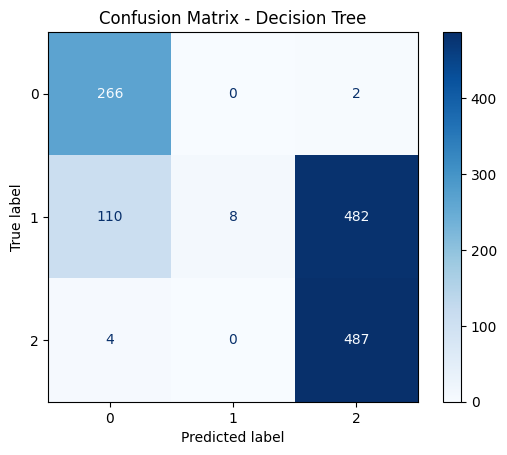

In [53]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion matrix untuk model Decision Tree (performa terbaik)
cm = confusion_matrix(y_test, dt_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dt_classifier.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Decision Tree')
plt.show()

#Deploy

In [54]:
checkpoint('Deploy')

In [55]:
import joblib
import os
import json
import datetime

# Check output_model_dir
if 'output_model_dir' not in globals() and 'output_model_dir' not in locals():
    output_model_dir = '/content/drive/My Drive/dataset_tubes/model2'

os.makedirs(output_model_dir, exist_ok=True)

# Simpan model dan preprocessor
joblib.dump(classifier, os.path.join(output_model_dir, 'svm2_classifier.pkl'))
joblib.dump(dt_classifier, os.path.join(output_model_dir, 'dt2_classifier.pkl'))
joblib.dump(knn_classifier, os.path.join(output_model_dir, 'knn2_classifier.pkl'))
joblib.dump(nn_classifier, os.path.join(output_model_dir, 'nn2_classifier.pkl'))
joblib.dump(scaler, os.path.join(output_model_dir, 'scaler.pkl'))

# Save metrics.json
timestamp = os.path.basename(output_model_dir).replace("model_", "")
if not timestamp or timestamp == "model2":
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

metrics_data = {
    "dt": float(dt_accuracy),
    "knn": float(knn_accuracy),
    "nn": float(mlp_accuracy),
    "svm": float(svm_accuracy),
    "timestamp": timestamp
}

metrics_path = os.path.join(output_model_dir, 'metrics.json')
with open(metrics_path, 'w', encoding='utf-8') as f:
    json.dump(metrics_data, f, indent=2)

print(f"Model and metrics saved successfully to {output_model_dir}")


Model and metrics saved successfully to model\model_20260530_120826


<span id="papermill-error-cell" style="color:red; font-family:Helvetica Neue, Helvetica, Arial, sans-serif; font-size:2em;">Execution using papermill encountered an exception here and stopped:</span>

In [56]:
checkpoint('Deploy', finalize=True, message='RETRAIN SELESAI')

AttributeError: module 'datetime' has no attribute 'utcnow'